In [1]:
using Pkg
Pkg.activate("./../julia-code")

  Activating project at `~/code/compositional/julia-code`


In [2]:
using Meris
using DataFrames, StatsBase
using CairoMakie, MakiePublication, LaTeXStrings
using Statistics

include("./../julia-code/scripts/module-scripts/macropatterns/MacroPatterns.jl")
using .MacroPatterns

In [3]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [10]:
big_df = Meris.arXivSampler.load(stopwords=true, DIR=Meris.ARXIVDIR * "lemmatized_noun_data/")
big_df = big_df[big_df.counts ./ big_df.nreads .< 1e-2, :];

In [11]:
# Create different dfs for the different scales
agg0 = deepcopy(big_df)
agg0.class .= agg0.domain .* "-" .* agg0.topic
select!(agg0, [:class, :component_id, :sample_id, :counts, :nreads])

agg1 = select(big_df, [:domain, :component_id, :sample_id, :counts, :nreads])
rename!(agg1, :domain => :class)

agg2 = select(big_df, [:component_id, :sample_id, :counts, :nreads])
agg2.class .= "arXiv";

In [24]:
df = deepcopy(agg0)
Meris.DataTools.df_filter!(df; min_samples=30, min_nreads=5e3)

println("--- AFD ---")
occ = 0.9
afd = MacroPatterns.compute_AFD(df; occ=occ, bins=25, verbose=true, save=false);

--- AFD ---
physics-soc-ph
physics-ao-ph
math-AT
math-AP
math-CT
astro-ph-CO
astro-ph-EP
astro-ph-SR
astro-ph-GA
q-bio-PE
q-bio-NC
q-bio-BM
q-bio-GN
cond-mat-mes-hall
cond-mat-quant-gas
cond-mat-dis-nn
cond-mat-mtrl-sci


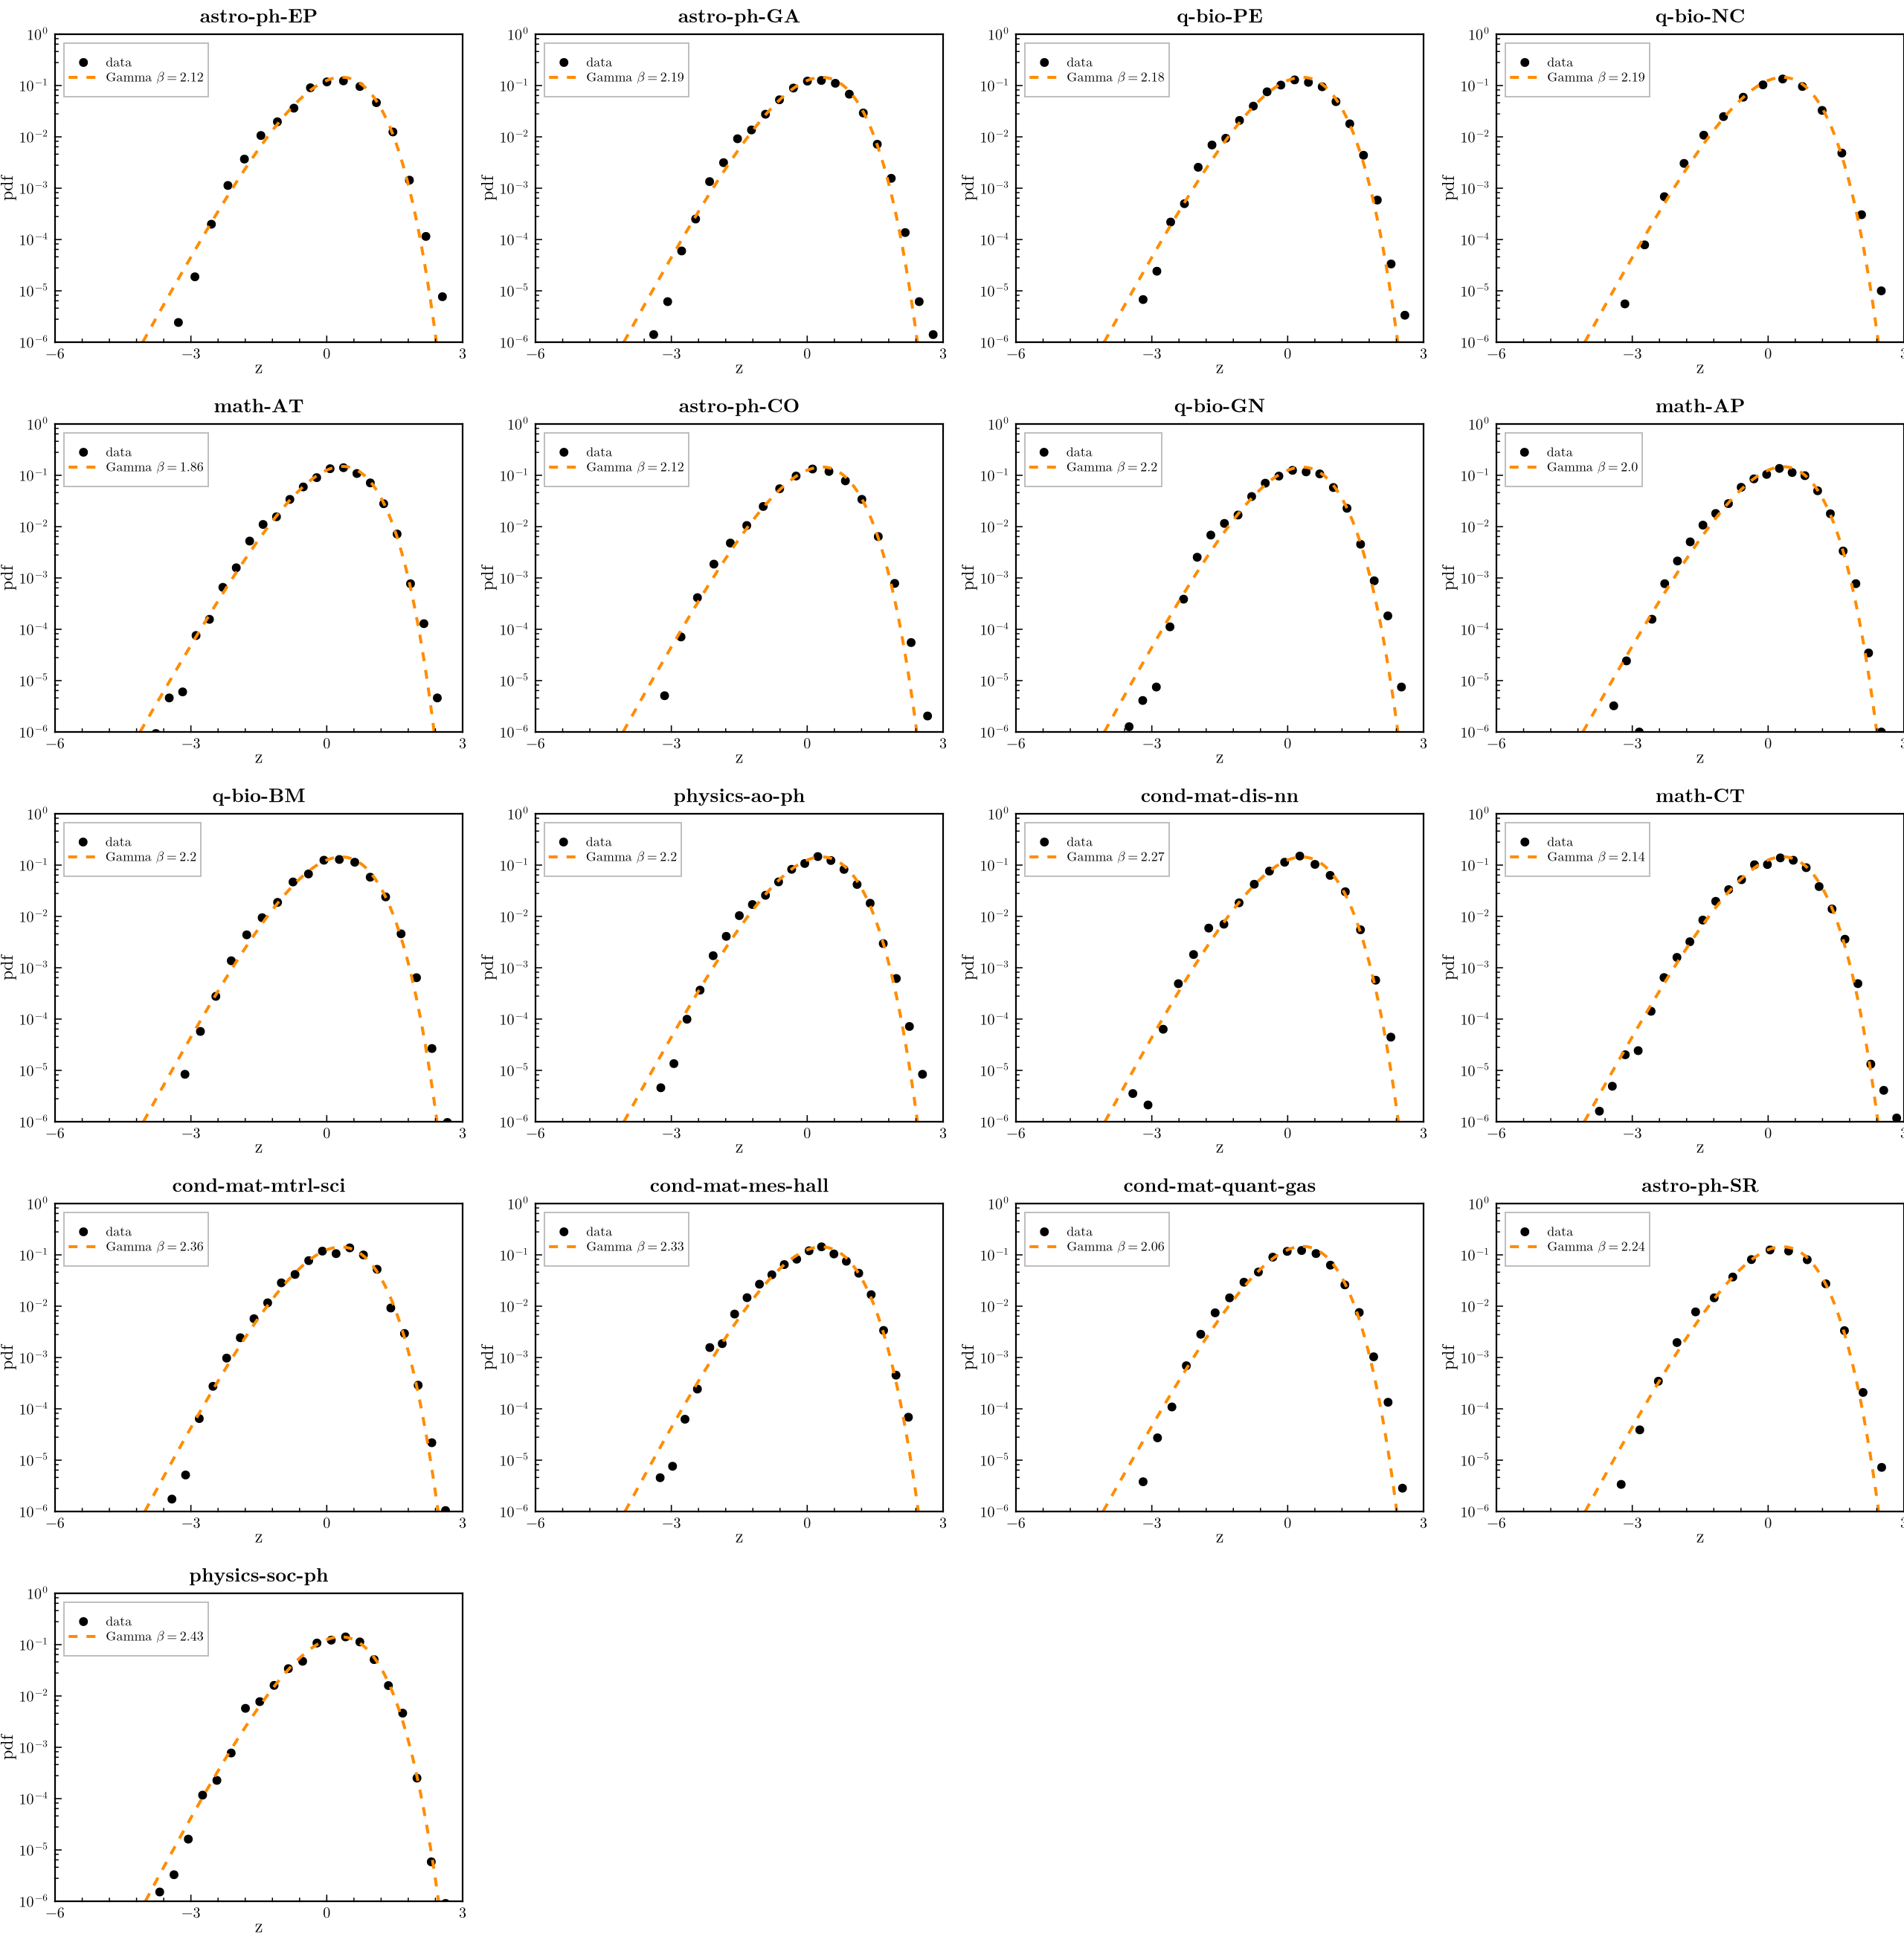

In [25]:
# Plot AFDs

# Collect environment names in a robust way
envs = afd isa AbstractDict ? collect(keys(afd)) : [e for (e, _) in afd]
nenv  = length(envs)

ncols = 4
if nenv == 1
    ncols =1
end
nrows = cld(nenv, ncols)            # ceil division
fig   = Figure(size=(320*ncols, 260*nrows))

# Global axis settings
xlims = (-6, 3)
ylims = (1e-6, 1e0)
zrange = -6:1e-2:3

for (i, e) in enumerate(envs)
    row = (i - 1) ÷ ncols + 1
    col = (i - 1) % ncols + 1
    ax = Axis(fig[row, col];
        title = string(e),
        yscale = log10,
        limits = (xlims, ylims),
        xlabel = L"\text{z}",
        ylabel = L"\text{pdf}",
        xlabelsize = 12, ylabelsize = 12, titlesize = 13,
        xticklabelsize = 10, yticklabelsize = 10
    )

    # Data for this environment
    x, y = afd isa AbstractDict ? afd[e] : only(last.(filter(p -> first(p) == e, afd)))

    # Parameters for this environment
    freqs = Meris.DataTools.get_frequencies(df[df.class .== e, :], occ=occ, rescale=false)
    μ = mean(freqs, dims=1)
    σ = std(freqs, dims=1)
    β = mean(μ .^2 ./ σ .^ 2)

    # Plots
    scatter!(ax, x, 10 .^ log.(y); markersize=7, label=L"\text{data}", color=:black)

    lines!(ax, zrange, 10 .^ Meris.LRDistr.lr_gamma(zrange, β);
           linewidth=2, linestyle=:dash, label=L"\text{Gamma } \beta = %$(round(β, digits=2))", color=:darkorange)
    
    # Legend inside each axis
    axislegend(ax; position=:lt, framevisible=true, labelsize=9, padding=3)
end

# Optional: tighten layout a bit
colgap!(fig.layout, 12)
rowgap!(fig.layout, 10)

fig
